<a href="https://colab.research.google.com/github/muhammetozcan07/smart_city_lighting/blob/main/smart_city_lighting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- TEST ADIMI 10 ---
Durum Verileri (Gerçeğe Uyarlanmış):
  - Hız: 47.5 km/s
  - Trafik Yoğunluğu: %16.4
  - Yağış: 0.00 mm
  - Hava Kodu: 3
  - Saat: 02:00

[Verideki İdeal Işık] : %25.0
[Yapay Zeka Kararı]  : %25
Alınan Puan          : 10.00
---------------------------------

Canlı Test Tamamlandı!



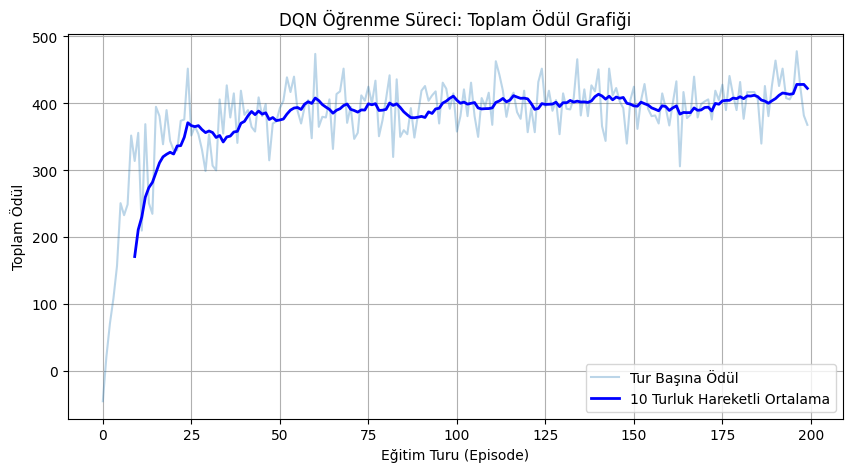

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import math

# ORTAM (ENVIRONMENT) TANIMLAMASI
class BerlinSmartLightingEnv:
    def __init__(self, csv_path):
        # Veriyi okuma ve hazırlama
        self.df = pd.read_csv(csv_path)
        self.max_steps = len(self.df) - 1

        # Durum (State) değişkenleri: Son sütun (Optimal_Lighting_Level) hariç sensör verileri
        self.state_columns = ['Speed [kmh]', 'Congestion level [%]', 'precipitation',
                              'weather_code', 'hour_sin', 'hour_cos']

        # Aksiyonlar ve gerçek parlaklık değerleri (0, 25, 50, 100)
        self.action_space = [0, 1, 2, 3]
        self.action_mapping = {0: 0, 1: 25, 2: 50, 3: 100}

        self.current_step = 0

    def reset(self):
        # Her turun (episode) başında veri seti içinden rastgele bir başlangıç noktası seçilir
        self.current_step = random.randint(0, self.max_steps - 100)
        return self._get_state()

    def _get_state(self):
        # Mevcut adımdaki sensör verilerini tensör formatında döndürür
        state_data = self.df.iloc[self.current_step][self.state_columns].values
        return torch.tensor(state_data, dtype=torch.float32)

    def step(self, action):
        state_data = self.df.iloc[self.current_step]
        optimal_light = state_data['Optimal_Lighting_Level']
        weather = state_data['weather_code']

        chosen_light = self.action_mapping[action]

        # TEMEL ÖDÜL
        if chosen_light == optimal_light:
            base_reward = 10
        else:
            base_reward = -abs(chosen_light - optimal_light) / 25.0

        # ENERJİ CEZASI
        energy_penalty = 0
        if chosen_light > optimal_light:
            energy_penalty = -1

        # GÜVENLİK CEZASI
        safety_penalty = 0
        is_bad_weather = weather >= 51
        if is_bad_weather and optimal_light > 0 and chosen_light == 0:
            safety_penalty = -5

        reward = base_reward + energy_penalty + safety_penalty

        self.current_step += 1
        done = self.current_step >= self.max_steps

        next_state = self._get_state() if not done else torch.zeros(len(self.state_columns))

        return next_state, reward, done, optimal_light

# YAPAY SİNİR AĞI (DEEP Q-NETWORK)
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        # Derin öğrenme katmanları
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# EĞİTİM ALGORİTMASI (DQN AGENT)
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.memory = deque(maxlen=10000)

        # Q-Learning Hiperparametreleri
        self.gamma = 0.99
        self.epsilon = 1.0         # Başlangıçta tamamen keşif
        self.epsilon_min = 0.01    # Keşif oranının düşebileceği minimum değer
        self.epsilon_decay = 0.995 # Her adımda rastgelelik azalır
        self.learning_rate = 0.001
        self.batch_size = 64

        # Model ve Optimizasyon
        self.model = DQN(state_dim, action_dim)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

    def act(self, state):
        # Epsilon-Greedy
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))

        with torch.no_grad():
            q_values = self.model(state.unsqueeze(0))
            return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)

        states = torch.stack([x[0] for x in batch])
        actions = torch.tensor([x[1] for x in batch])
        rewards = torch.tensor([x[2] for x in batch], dtype=torch.float32)
        next_states = torch.stack([x[3] for x in batch])
        dones = torch.tensor([x[4] for x in batch], dtype=torch.float32)

        # Bellman denkleminin sinir ağına uyarlanması
        q_values = self.model(states)
        next_q_values = self.model(next_states)

        target_q_values = q_values.clone()

        for i in range(self.batch_size):
            if dones[i]:
                target_q_values[i][actions[i]] = rewards[i]
            else:
                target_q_values[i][actions[i]] = rewards[i] + self.gamma * torch.max(next_q_values[i])

        # Ağı Güncelleme
        loss = self.criterion(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Öğrenme süreci boyunca rastgeleliği (epsilon) azaltma
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# --- EĞİTİM KISMI ---
env = BerlinSmartLightingEnv('Berlin_RL_Environment.csv')
state_dim = len(env.state_columns)
action_dim = len(env.action_space)

agent = DQNAgent(state_dim, action_dim)
episodes = 200        # Yapay zekanın eğitileceği tur sayısı
steps_per_episode = 50 # Her turdaki adım sayısı

rewards_history = []

print("Derin Pekiştirmeli Öğrenme (DQN) Eğitimi Başlıyor...")
for e in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(steps_per_episode):
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)

        # Deneyimi kaydet ve ağı eğit
        agent.remember(state, action, reward, next_state, done)
        agent.replay()

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_history.append(total_reward)

    # Her 20 adımda bir ilerlemeyi ekrana yazdır
    if (e+1) % 20 == 0:
        print(f"Bölüm (Episode): {e+1}/{episodes} | Toplam Ödül: {total_reward:.2f} | Keşif Oranı (Epsilon): {agent.epsilon:.3f}")

print("Eğitim Tamamlandı!\n")

# --- GRAFİK KISMI ---
plt.figure(figsize=(10,5))
window = 10
moving_avg = pd.Series(rewards_history).rolling(window=window).mean()
plt.plot(rewards_history, alpha=0.3, label='Tur Başına Ödül')
plt.plot(moving_avg, color='blue', linewidth=2, label=f'{window} Turluk Hareketli Ortalama')
plt.title('DQN Öğrenme Süreci: Toplam Ödül Grafiği')
plt.xlabel('Eğitim Turu (Episode)')
plt.ylabel('Toplam Ödül')
plt.legend()
plt.grid(True)
plt.show(block=False)
plt.pause(2)

# Çevresel Verilerin İnsan Tarafından Okunabilir Hale Getirilmesi
def unscale_for_display(state_array, columns):
    display_dict = {}

    for i, col in enumerate(columns):
        val = state_array[i]

        if col == 'Speed [kmh]':
            real_speed = max(0, (val * 15) + 40)
            display_dict['Hız'] = f"{real_speed:.1f} km/s"

        elif col == 'Congestion level [%]':
            real_congestion = max(0, min(100, (val * 20) + 40))
            display_dict['Trafik Yoğunluğu'] = f"%{real_congestion:.1f}"

        elif col == 'precipitation':
            real_precip = max(0, (val * 0.5) + 0.1)
            display_dict['Yağış'] = f"{real_precip:.2f} mm"

        elif col == 'weather_code':
            display_dict['Hava Kodu'] = f"{int(val)}"



    # Saat sin/cos değerlerini 0-23 arası gerçek saate (Hour) çevirme:
    sin_idx = columns.index('hour_sin')
    cos_idx = columns.index('hour_cos')
    hour_sin = state_array[sin_idx]
    hour_cos = state_array[cos_idx]

    # arctan2 fonksiyonu ile açıyı bulup 24 saate oranlıyoruz
    hour_real = round((math.atan2(hour_sin, hour_cos) * 24 / (2 * math.pi))) % 24
    display_dict['Saat'] = f"{hour_real:02d}:00"

    return display_dict

# --- SİMÜLASYON (TEST) KISMI ---
print("\nSistemi Çeşitli Senaryolarla Canlı Test Ediyoruz... (10 Adım)")
time.sleep(2)

for step in range(10):
    clear_output(wait=True)

    state = env.reset()

    with torch.no_grad():
        q_values = agent.model(state.unsqueeze(0))
        action = torch.argmax(q_values).item()

    next_state, reward, done, optimal_light = env.step(action)
    chosen_light = env.action_mapping[action]

    human_readable_state = unscale_for_display(state.numpy(), env.state_columns)

    print(f"--- TEST ADIMI {step + 1} ---")
    print("Durum Verileri (Gerçeğe Uyarlanmış):")
    for key, val in human_readable_state.items():
        print(f"  - {key}: {val}")

    print(f"\n[Verideki İdeal Işık] : %{optimal_light}")
    print(f"[Yapay Zeka Kararı]  : %{chosen_light}")
    print(f"Alınan Puan          : {reward:.2f}")
    print("---------------------------------\n")

    time.sleep(2.5)

print("Canlı Test Tamamlandı!\n")

# --- GRAFİK KISMI ---
plt.figure(figsize=(10,5))
window = 10
moving_avg = pd.Series(rewards_history).rolling(window=window).mean()
plt.plot(rewards_history, alpha=0.3, label='Tur Başına Ödül')
plt.plot(moving_avg, color='blue', linewidth=2, label=f'{window} Turluk Hareketli Ortalama')
plt.title('DQN Öğrenme Süreci: Toplam Ödül Grafiği')
plt.xlabel('Eğitim Turu (Episode)')
plt.ylabel('Toplam Ödül')
plt.legend()
plt.grid(True)
plt.show(block=True)